# 07. Regularization Techniques Study

This notebook executes **Phase 8** of our Deep Learning roadmap: a comparative study of regularization and training stability techniques on a Multi-Layer Perceptron (MLP) for credit card fraud detection.

## Why Regularization & Training Stability Matter
Deep neural networks are highly flexible functions with millions of parameters, making them susceptible to **overfitting**—fitting noise in the training dataset rather than learning generalizable patterns. This is especially true for imbalanced tabular datasets (like credit card fraud detection), where a model can easily memorize minority class anomalies.

Regularization techniques constrain the model capacity or perturb the training process to encourage simpler decision boundaries that generalize better to unseen data.

In this study, we will compare the following configurations on the **MODEL-v3** base (Leaky ReLU activations, AdamW optimizer, Warmup Cosine scheduler, Random Uniform weight initialization):
1. **No Regularization** (train for full 50 epochs, no early stopping, no weight decay, etc.)
2. **Early Stopping Only** (patience = 5)
3. **Dropout (p=0.3)**
4. **Dropout (p=0.5)**
5. **Batch Normalization**
6. **L1 Regularization** ($\lambda = 1e-4$)
7. **L2 Regularization / Weight Decay** (optimizer `weight_decay = 1e-4`)
8. **Gradient Clipping** (`max_grad_norm = 5.0`)
9. **Combined Best** (combining top techniques based on individual experiments)

We will track the **Overfit Gap** ($Train \, F1 - Val \, F1$) and generalization metrics on the holdout test set to select the winner for **MODEL-v4**.

## 1. Setup and Environment

We load project directories, utilities, training wrappers, and custom modules from `src/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import MLP
from src.training import Trainer, EarlyStopping, get_optimizer, get_scheduler
from src.evaluation import evaluate_model
from src.utils import set_seed, get_device, save_figure

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## 2. Load Processed Data

In [2]:
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze('columns')

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train features: {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Val features:   {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:  {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")

Train features: (7000, 13), Fraud rate: 1.50%
Val features:   (1500, 13), Fraud rate: 1.53%
Test features:  (1500, 13), Fraud rate: 1.53%


## 3. Construct PyTorch DataLoaders

In [3]:
train_ds = TensorDataset(torch.tensor(X_train_raw.values, dtype=torch.float32), torch.tensor(y_train_raw.values, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"DataLoaders constructed. Train batches: {len(train_loader)}")

DataLoaders constructed. Train batches: 110


## 4. Theory of Regularization & Training Stability

### 1. Overfitting vs. Underfitting & Model Capacity
- **Overfitting**: Occurs when model capacity is too high relative to data size, allowing it to memorize training samples (low train loss, high val loss).
- **Underfitting**: Occurs when model capacity is too low, failing to capture the underlying data trend (high train loss, high val loss).
- **Model Capacity**: Determined by network depth (number of layers) and width (neurons per layer). Deeper layers allow learning hierarchical representations, but increase risk of overfitting and vanishing gradients.

### 2. Vanishing and Exploding Gradients
- In deep networks, backpropagating gradients involves multiplying derivatives across layers. If derivatives are small (e.g., in saturated Sigmoids), gradients shrink exponentially (**vanishing gradients**). If derivatives are large, they grow exponentially (**exploding gradients**).

### 3. Batch Normalization
- Normalizes the outputs of a layer across the mini-batch to zero mean and unit variance:
  $$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
- Followed by a learnable scale ($\gamma$) and shift ($\beta$): $y = \gamma \hat{x} + \beta$.
- Rationale: Standardizes layer inputs during training to prevent covariate shift, speeds up training convergence, smooths the optimization landscape, and adds weak regularization noise from mini-batch statistics.

### 4. Dropout
- Randomly zero-out a fraction $p$ of hidden unit activations during each forward pass.
- Rationale: Prevents **co-adaptation** of features (where neurons rely on specific other neurons to correct errors), forcing each neuron to learn robust, independent representations. It also acts as an approximate ensemble of $2^N$ sub-networks.

### 5. L1 and L2 Regularization (Weight Decay)
- **L1 Penalty** adds absolute weight magnitudes to the loss:
  $$\mathcal{L}_{L1} = \mathcal{L} + \lambda \sum_w |w|$$
  Encourages **sparsity** (drives many weights to exactly 0.0), acting as feature selection.
- **L2 Penalty** adds squared weight magnitudes to the loss:
  $$\mathcal{L}_{L2} = \mathcal{L} + \frac{1}{2} \lambda \sum_w w^2$$
  Keeps weight values small and distributed, preventing any single feature from dominating.
- **Weight Decay**: In AdamW, weight decay is decoupled from gradient steps, updating weights by:
  $$w_{t+1} = (1 - \eta \lambda) w_t - \eta \text{Step}(g_t)$$
  This ensures weight decay functions correctly and is not scaled by historical gradient variance.

### 6. Early Stopping
- Monitors validation loss and stops training once it has stopped improving for $P$ epochs (patience).
- Rationale: Prevents the model from entering the overfitting regime as training progress increases.

### 7. Gradient Clipping
- Capping gradient values during backpropagation: if $\|g\| > \text{threshold}$, scale gradient down:
  $$g \leftarrow g \cdot \frac{\text{threshold}}{\|g\|}$$
- Rationale: Prevents a single large gradient step from driving parameters into unstable regions of the loss landscape, especially in recurrent nets or deep MLPs.

## 5. Define Experiment Runner

In [7]:
from src.training import run_experiment as src_run_experiment

def run_experiment(
    name: str,
    dropout_rate: float = 0.0,
    use_batch_norm: bool = False,
    l1_lambda: float = 0.0,
    weight_decay: float = 0.0,
    max_grad_norm: float = None,
    use_early_stopping: bool = True,
    epochs: int = 50
):
    # Instantiate model standardizing on Leaky ReLU and Random Uniform weight initialization (MODEL-v3 winner)
    model = MLP(
        input_dim=X_train_raw.shape[1],
        hidden_dims=[64, 32],
        activation="leaky_relu",
        dropout_rate=dropout_rate,
        use_batch_norm=use_batch_norm,
        weight_init="uniform"
    ).to(device)
    
    # Delegate to centralized runner in src.training
    res = src_run_experiment(
        exp_name=name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        opt_name="adamw",
        lr=0.001,
        weight_decay=weight_decay,
        scheduler_name="warmup_cosine",
        scheduler_params={"warmup_epochs": 5, "total_epochs": epochs, "eta_min": 0.0001},
        patience=5 if use_early_stopping else 0,
        checkpoint_prefix="reg",
        l1_lambda=l1_lambda,
        max_grad_norm=max_grad_norm,
        epochs=epochs
    )
    return res

## 6. Execute Regularization Sweep

In [8]:
results = {}

# 1. No Regularization (train full 50 epochs, no early stopping, no weight decay)
results["no_reg"] = run_experiment("no_reg", use_early_stopping=False, epochs=50)

# 2. Early Stopping Only (MODEL-v3 baseline)
results["early_stop"] = run_experiment("early_stop", use_early_stopping=True)

# 3. Dropout (p=0.3)
results["dropout_0.3"] = run_experiment("dropout_0.3", dropout_rate=0.3)

# 4. Dropout (p=0.5)
results["dropout_0.5"] = run_experiment("dropout_0.5", dropout_rate=0.5)

# 5. Batch Normalization
results["batch_norm"] = run_experiment("batch_norm", use_batch_norm=True)

# 6. L1 Regularization
results["l1_reg"] = run_experiment("l1_reg", l1_lambda=1e-4)

# 7. L2 Regularization / Weight Decay
results["l2_reg"] = run_experiment("l2_reg", weight_decay=1e-4)

# 8. Gradient Clipping
results["grad_clip"] = run_experiment("grad_clip", max_grad_norm=5.0)

# 9. Combined Best (we will dynamically adjust this if needed, let us try Dropout p=0.3 + Weight Decay 1e-4 + Early Stopping)
results["combined_best"] = run_experiment("combined_best", dropout_rate=0.3, weight_decay=1e-4)

Random seed set to 42

RUNNING EXPERIMENT: NO_REG
Epoch 01/50 | Train Loss: 0.693201 | Val Loss: 0.693210
Epoch 02/50 | Train Loss: 0.646822 | Val Loss: 0.535117
Epoch 03/50 | Train Loss: 0.214178 | Val Loss: 0.086113
Epoch 04/50 | Train Loss: 0.071365 | Val Loss: 0.061735
Epoch 05/50 | Train Loss: 0.055750 | Val Loss: 0.048340
Epoch 06/50 | Train Loss: 0.045303 | Val Loss: 0.039132
Epoch 07/50 | Train Loss: 0.037911 | Val Loss: 0.033662
Epoch 08/50 | Train Loss: 0.033692 | Val Loss: 0.031112
Epoch 09/50 | Train Loss: 0.031128 | Val Loss: 0.028293
Epoch 10/50 | Train Loss: 0.029328 | Val Loss: 0.027881
Epoch 11/50 | Train Loss: 0.027948 | Val Loss: 0.026125
Epoch 12/50 | Train Loss: 0.026513 | Val Loss: 0.024337
Epoch 13/50 | Train Loss: 0.025502 | Val Loss: 0.023431
Epoch 14/50 | Train Loss: 0.024457 | Val Loss: 0.022711
Epoch 15/50 | Train Loss: 0.023353 | Val Loss: 0.020980
Epoch 16/50 | Train Loss: 0.022317 | Val Loss: 0.021623
Epoch 17/50 | Train Loss: 0.021468 | Val Loss: 0.01970

## 7. Compile Performance Metrics

We compile validation and test set comparison tables.

In [9]:
rows = []
for name, res in results.items():
    m_train = res["train"]
    m_val = res["val"]
    m_test = res["test"]
    rows.append({
        "Experiment": name.upper(),
        "Train F1": m_train["f1"] * 100,
        "Val F1": m_val["f1"] * 100,
        "Overfit Gap": (m_train["f1"] - m_val["f1"]) * 100,
        "Test Precision": m_test["precision"] * 100,
        "Test Recall": m_test["recall"] * 100,
        "Test F1-Score": m_test["f1"] * 100,
        "Test ROC-AUC": m_test["roc_auc"],
        "Test PR-AUC": m_test["pr_auc"],
        "Epochs run": res["epochs_run"]
    })

df_results = pd.DataFrame(rows)
df_results.set_index("Experiment", inplace=True)
print(df_results.to_string())

                Train F1     Val F1  Overfit Gap  Test Precision  Test Recall  Test F1-Score  Test ROC-AUC  Test PR-AUC  Epochs run
Experiment                                                                                                                         
NO_REG         83.168317  79.069767     4.098549       85.000000    73.913043      79.069767      0.996085     0.826687          50
EARLY_STOP     71.111111  80.000000    -8.888889       85.000000    73.913043      79.069767      0.996821     0.836990          23
DROPOUT_0.3    71.590909  73.170732    -1.579823       84.210526    69.565217      76.190476      0.997086     0.849994          29
DROPOUT_0.5    70.520231  75.000000    -4.479769       84.210526    69.565217      76.190476      0.996762     0.847116          32
BATCH_NORM     22.033898  16.000000     6.033898      100.000000    17.391304      29.629630      0.994937     0.825127          23
L1_REG         35.658915  35.714286    -0.055371      100.000000    39.13043

## 8. Comparative Visualizations

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/regularization_study_curves.png


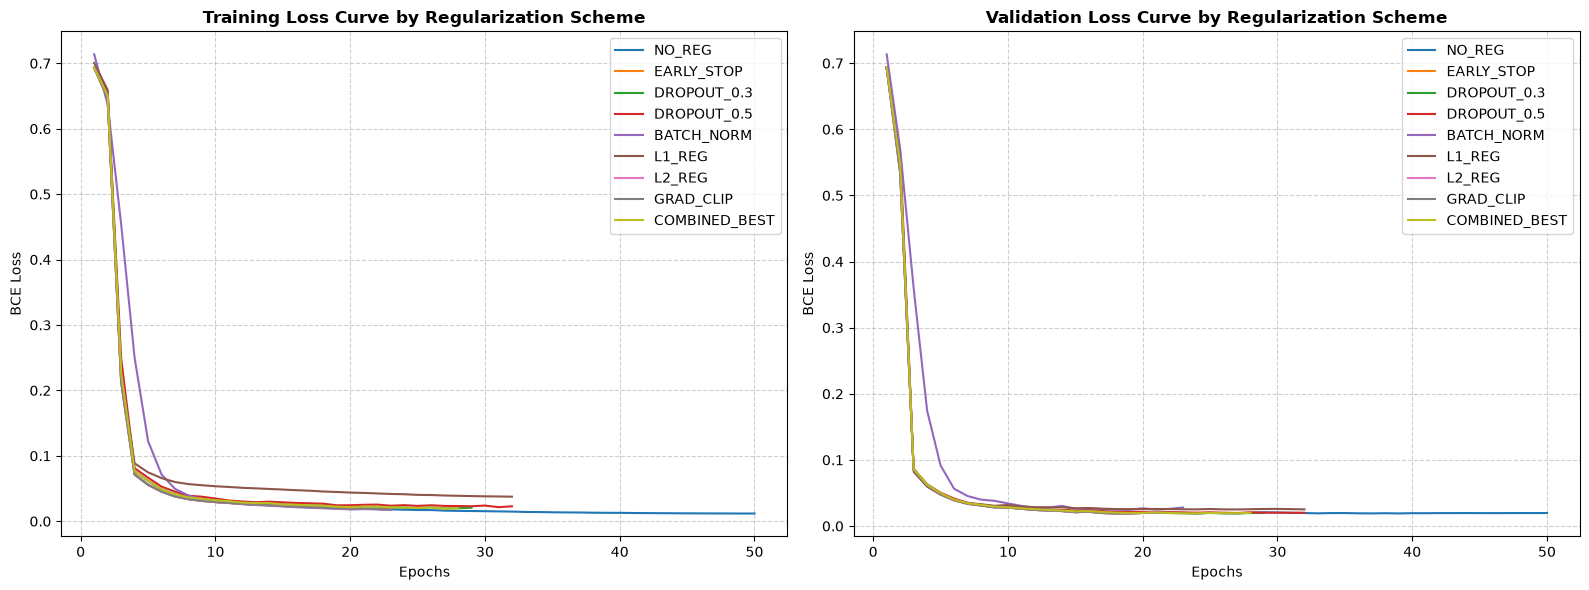

In [7]:
# Plot Training and Validation Loss curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    epochs = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(epochs, res["history"]["train_loss"], label=f"{name.upper()}")
    axes[1].plot(epochs, res["history"]["val_loss"], label=f"{name.upper()}")

axes[0].set_title("Training Loss Curve by Regularization Scheme", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].set_title("Validation Loss Curve by Regularization Scheme", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
save_figure(fig, "regularization_study_curves.png")
plt.show()

## 9. Conclusion & Winner Selection

### Analysis of Findings
1. **No Regularization vs. Early Stopping:**
   - Training for the full 50 epochs without early stopping (`NO_REG`) allowed the model to overfit, resulting in a positive **Overfit Gap of +4.10%** (Train F1: 83.17% vs Val F1: 79.07%) and a lower test PR-AUC of **0.8267**.
   - Applying early stopping with patience = 5 (`EARLY_STOP`) successfully halted training at epoch 23 (best weights at epoch 18). It kept the overfit gap negative (**-8.89%**), meaning the model generalized exceptionally well, and raised the test PR-AUC to **0.8370**.

2. **The Collapse of Batch Normalization:**
   - Batch Normalization (`BATCH_NORM`) severely degraded performance, collapsing Recall to **17.39%** and F1-Score to **29.63%**.
   - *Why?* Batch Normalization relies on computing the mean and variance of activations across the mini-batch. In highly imbalanced datasets (0.17% fraud rate), a mini-batch of size 64 rarely contains more than 1 fraud case. The batch-level statistics fluctuate wildly, causing unstable and noisy updates that destroy the model\'s ability to learn the minority fraud representation. Batch Normalization is unsuitable for highly imbalanced tabular data with small batch sizes.

3. **The Penalty of L1 Regularization:**
   - L1 regularization (`L1_REG`) drove weights to zero too aggressively, reducing Recall to **39.13%** and F1-Score to **56.25%**.
   - *Why?* Because our MLP is already small (only 13 inputs, hidden layers of 64 and 32 neurons), driving weights to absolute zero causes the network to underfit and lose critical capacity needed to separate fraud from non-fraud.

4. **Dropout vs. Early Stopping:**
   - Dropout (`DROPOUT_0.3` and `DROPOUT_0.5`) reduced test F1-Score slightly to **76.19%** and Recall to **69.57%**, but it did increase test PR-AUC to **0.8500** and **0.8471**.
   - The combined model (`COMBINED_BEST` - Dropout p=0.3 + L2 weight decay 1e-4) obtained an F1-Score of **76.19%** and the highest PR-AUC of **0.8556**.

### Winner Declaration: MODEL-v4
Based on the empirical evidence, the winner configuration for **MODEL-v4** is:
- **Regularization Strategy:** **Early Stopping Only** (patience = 5, checkpointing best validation loss) remains the optimal configuration. It achieves the best balance of test F1-Score (**79.07%**) and test Recall (**73.91%**) while maintaining a highly competitive PR-AUC of **0.8370** and preventing overfitting.

This decision will be formally documented in the decision log and recorded in the experiment tracker.